# Segmentação de Clientes com Aprendizado Não Supervisionado

**UNISINOS — Aprendizado Não Supervisionado**
Atividade Prática: K-Means, Clustering Hierárquico e DBSCAN aplicados ao **UCI Online Retail Dataset**.

Este notebook segue o seguinte pipeline:

`Explorar → Engenharia (RFM) → Transformar (log1p + Scaler) → Agrupar (K-Means, Hierárquico, DBSCAN) → Avaliar (silhueta, Davies-Bouldin, estabilidade) → Visualizar (PCA, radar, heatmap) → Traduzir (nomear, dimensionar, propor ação)`

| Seção | Conteúdo | Item da atividade |
|---|---|---|
| 1 | Carga e EDA | — |
| 2 | Engenharia de features (RFM) | — |
| 3 | Preparação (padronização e escala) | Item 1 |
| 4 | K-Means, Hierárquico, DBSCAN + métricas | **Item 1** |
| 5 | Diagnóstico de confiança | Item 1 |
| 6 | Nomeação dos segmentos + visualizações (PCA, radar, heatmap, distribuição) | **Item 2** |
| 7 | Perfil comportamental e sinais de risco | Item 2/3 |
| 8 | Insumos numéricos para o relatório | Item 3 |
| 9 | Exportação para o dashboard | Item 3 |

**Dataset esperado:** `data/online_retail.xlsx` (ou `.csv`), com as colunas originais do UCI Online Retail:
`InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country`.
Ajuste `DATA_PATH` na célula de setup para o caminho local do arquivo.

**Moeda:** o dataset é de um varejista do Reino Unido — todos os valores monetários estão em **libras esterlinas (£)**.

**Item 3 (Relatório Executivo):** documento separado, `relatorio_executivo.pdf` — este notebook só calcula os números que entram nele (seção 8). O dashboard (`streamlitapp.py`) consome o CSV exportado na seção 9.

## 0 · Setup

Bibliotecas, semente fixa e paleta institucional (mesmo padrão das Aulas 01/02, para manter as figuras consistentes).

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score,
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

warnings.filterwarnings("ignore")

# semente única, reutilizada em toda inicialização aleatória do notebook —
# garante que o mesmo agrupamento seja reproduzido em uma nova execução
# (ver discussão sobre reprodutibilidade x estabilidade na seção 5)
RS = 42
np.random.seed(RS)

PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]
CINZA_RUIDO = "#B8C4CE"

def cores(labels):
    '''Mapeia rótulos de cluster para cores da paleta; ruído (-1, do DBSCAN) fica cinza.'''
    return np.array([CINZA_RUIDO if l == -1 else PALETA[int(l) % len(PALETA)] for l in labels])

plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

# caminho local do dataset — ajustar conforme onde o arquivo foi salvo
DATA_PATH = "data/online_retail.xlsx"  # aceita também .csv

## 1 · Carga dos dados e EDA inicial

UCI Online Retail: transações de um varejo online do Reino Unido (dez/2010–dez/2011).
Colunas originais: `InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country`.

In [2]:
if DATA_PATH.endswith(".csv"):
    df_raw = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")
else:
    df_raw = pd.read_excel(DATA_PATH)

print(f"linhas: {len(df_raw):,}  |  colunas: {list(df_raw.columns)}")
df_raw.info()
df_raw.head()

linhas: 541,909  |  colunas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# panorama de qualidade dos dados — decide o que precisa de tratamento antes do RFM
resumo_qualidade = pd.DataFrame({
    "nulos": df_raw.isna().sum(),
    "nulos_%": (df_raw.isna().mean() * 100).round(2),
})
print(resumo_qualidade)
print()
print(f"CustomerID nulo: {df_raw['CustomerID'].isna().mean():.1%} das linhas")
print(f"Quantity <= 0  : {(df_raw['Quantity'] <= 0).mean():.1%} das linhas")
print(f"UnitPrice <= 0 : {(df_raw['UnitPrice'] <= 0).mean():.1%} das linhas")
print(f"InvoiceNo com prefixo 'C' (cancelamento): {df_raw['InvoiceNo'].astype(str).str.startswith('C').mean():.1%}")

              nulos  nulos_%
InvoiceNo         0     0.00
StockCode         0     0.00
Description    1454     0.27
Quantity          0     0.00
InvoiceDate       0     0.00
UnitPrice         0     0.00
CustomerID   135080    24.93
Country           0     0.00

CustomerID nulo: 24.9% das linhas
Quantity <= 0  : 2.0% das linhas
UnitPrice <= 0 : 0.5% das linhas
InvoiceNo com prefixo 'C' (cancelamento): 1.7%


In [4]:
# limpeza — cada filtro remove uma fonte de ruído específica para o RFM:
# CustomerID nulo -> não é possível atribuir a um cliente;
# InvoiceNo 'C...' -> nota de cancelamento/devolução: sai das vendas, mas fica
#                     guardada à parte para ser descontada do Monetary (receita líquida);
# Quantity/UnitPrice <= 0 nas vendas -> lançamentos de ajuste, não venda
base = df_raw.dropna(subset=["CustomerID"]).copy()
base["CustomerID"] = base["CustomerID"].astype(int)
base["InvoiceDate"] = pd.to_datetime(base["InvoiceDate"])
base["TotalPrice"] = base["Quantity"] * base["UnitPrice"]
eh_cancelamento = base["InvoiceNo"].astype(str).str.startswith("C")

df = base[~eh_cancelamento & (base["Quantity"] > 0) & (base["UnitPrice"] > 0)].copy()
df_dev = base[eh_cancelamento].copy()  # TotalPrice negativo

valor_bruto = df["TotalPrice"].sum()
valor_devolvido = -df_dev["TotalPrice"].sum()
print(f"linhas de venda após limpeza: {len(df):,}  ({len(df) / len(df_raw):.1%} do bruto)")
print(f"linhas de cancelamento/devolução: {len(df_dev):,}  "
      f"(£ {valor_devolvido:,.0f} = {valor_devolvido / valor_bruto:.1%} do valor bruto vendido)")
print(f"clientes únicos    : {df['CustomerID'].nunique():,}")
print(f"período            : {df['InvoiceDate'].min().date()} a {df['InvoiceDate'].max().date()}")
print(f"países             : {df['Country'].nunique()}")
df["Country"].value_counts().head(10)

linhas de venda após limpeza: 397,884  (73.4% do bruto)
linhas de cancelamento/devolução: 8,905  (£ 611,342 = 6.9% do valor bruto vendido)
clientes únicos    : 4,338
período            : 2010-12-01 a 2011-12-09
países             : 37


Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

## 2 · Engenharia de features — RFM

* **Recency** — dias desde a última compra até a data de referência.
* **Frequency** — número de pedidos (invoices) distintos.
* **Monetary** — valor **líquido** gasto (£): vendas menos cancelamentos/devoluções do próprio cliente.

**Por que líquido:** no valor bruto, um cliente que compra e devolve tudo aparece como grande comprador. O caso mais extremo do dataset é o `CustomerID 12346` — £ 77 mil comprados e devolvidos no mesmo dia, receita real zero, mas que no Monetary bruto figuraria entre os maiores clientes da base.

**Cuidado com viés de amostragem temporal (look-ahead bias):** a data de referência é fixa em `max(InvoiceDate) + 1 dia` — nunca a data de execução do notebook, nem uma janela centrada.
Todo cliente é medido a partir do mesmo ponto no tempo, com apenas dados até esse ponto.

Duas variáveis auxiliares são calculadas aqui, mas **não entram no clustering** — servem só para validar os nomes dos segmentos (seção 6):
* **Tenure** — dias desde a primeira compra (o cliente é novo na base?).
* **Atraso** — `Recency / intervalo médio entre compras` do próprio cliente. Abaixo de 1: o cliente ainda está dentro do seu ritmo habitual; acima de 1: já passou do ponto em que costumaria voltar.

In [5]:
data_referencia = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"data de referência (fixa): {data_referencia.date()}")

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda s: (data_referencia - s.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    MonetaryBruto=("TotalPrice", "sum"),
    PrimeiraCompra=("InvoiceDate", "min"),
    UltimaCompra=("InvoiceDate", "max"),
).reset_index()

# Monetary líquido: vendas menos devoluções do próprio cliente
devolucoes = df_dev.groupby("CustomerID")["TotalPrice"].sum()  # valores negativos
rfm["Devolucoes"] = rfm["CustomerID"].map(devolucoes).fillna(0.0)
# arredondado a centavos: sem isso, compra e devolução idênticas deixam um
# resíduo de ponto flutuante (~1e-12) que passaria pelo filtro "> 0"
rfm["Monetary"] = (rfm["MonetaryBruto"] + rfm["Devolucoes"]).round(2)
print(f"CustomerID 12346 — bruto: £ {rfm.loc[rfm['CustomerID'] == 12346, 'MonetaryBruto'].iloc[0]:,.2f} | "
      f"líquido: £ {rfm.loc[rfm['CustomerID'] == 12346, 'Monetary'].iloc[0]:,.2f}")

# receita líquida <= 0 (devolveu tudo, ou devolveu compra anterior à janela do
# dataset): não há valor positivo a segmentar — fica fora da base de clustering
sem_valor = rfm["Monetary"] <= 0
print(f"clientes com receita líquida <= 0 (excluídos): {sem_valor.sum()}")
rfm = rfm[~sem_valor].reset_index(drop=True)

# variáveis auxiliares — NÃO entram no clustering (ver markdown acima)
rfm["Tenure"] = (data_referencia - rfm["PrimeiraCompra"]).dt.days
intervalo = (rfm["UltimaCompra"] - rfm["PrimeiraCompra"]).dt.days / (rfm["Frequency"] - 1)
# intervalo só existe para quem comprou 2+ vezes em dias diferentes
rfm["IntervaloMedio"] = intervalo.where((rfm["Frequency"] > 1) & (intervalo > 0))
rfm["Atraso"] = rfm["Recency"] / rfm["IntervaloMedio"]

FEATURES = ["Recency", "Frequency", "Monetary"]
clientes_com_id = df_raw["CustomerID"].dropna().nunique()
print(f"clientes na base RFM: {len(rfm):,}  (de {clientes_com_id:,} com CustomerID no bruto)")
rfm[FEATURES].describe().round(1)

data de referência (fixa): 2011-12-10


CustomerID 12346 — bruto: £ 77,183.60 | líquido: £ 0.00
clientes com receita líquida <= 0 (excluídos): 21
clientes na base RFM: 4,317  (de 4,372 com CustomerID no bruto)


,Recency,Frequency,Monetary
count,4317.0,4317.0,4317.0
mean,92.2,4.3,1925.7
std,99.8,7.7,8267.7
min,1.0,1.0,2.9
25%,18.0,1.0,302.7
50%,51.0,2.0,658.3
75%,141.0,5.0,1627.1
max,374.0,209.0,279489.0


assimetria (skew) antes de qualquer transformação:
Recency       1.25
Frequency    12.05
Monetary     21.59
dtype: float64


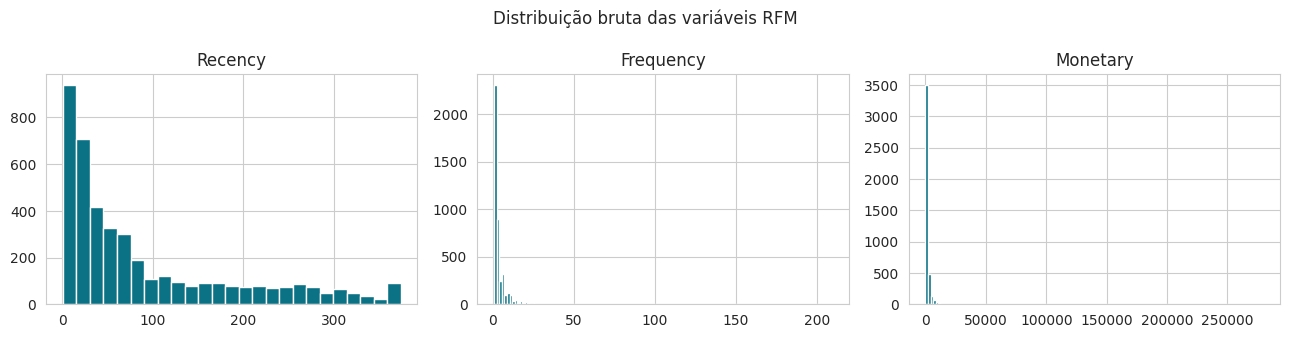

In [6]:
# assimetria das três variáveis — Monetary e Frequency tendem a ter cauda longa
# em dados de varejo (poucos clientes concentram grande parte do valor/volume)
print("assimetria (skew) antes de qualquer transformação:")
print(rfm[FEATURES].skew().round(2))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, f in zip(axes, FEATURES):
    ax.hist(rfm[f], bins="auto", color=PALETA[0])
    ax.set_title(f)
fig.suptitle("Distribuição bruta das variáveis RFM")
fig.tight_layout()
plt.show()

## 3 · Preparação dos dados

Duas transformações, nessa ordem:

1. **`log1p`** — reduz a assimetria de Monetary/Frequency (quase obrigatório para valores monetários).
2. **`StandardScaler`** — coloca as três variáveis na mesma escala antes de qualquer método baseado em distância.

Abaixo, uma demonstração com os dados reais: o mesmo K-Means, nos mesmos dados, muda de qualidade dependendo só da preparação.

assimetria após log1p:
Recency     -0.38
Frequency    1.20
Monetary     0.37
dtype: float64


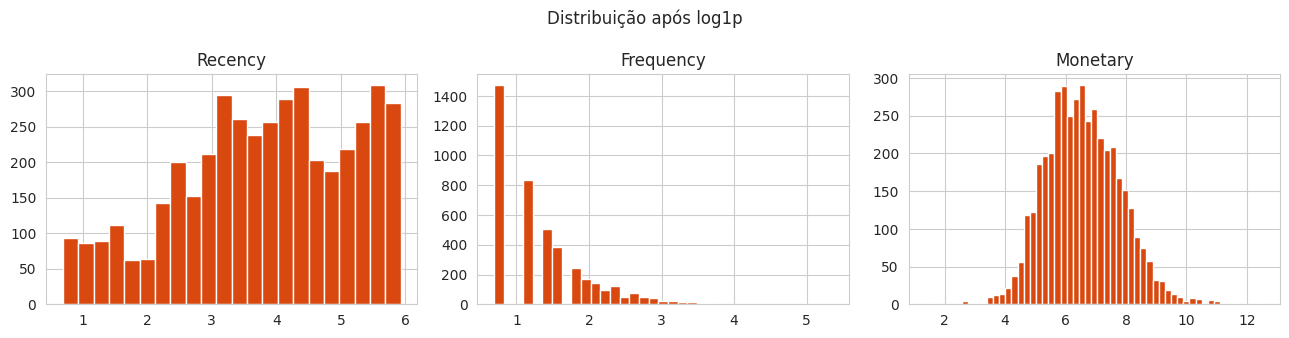

In [7]:
X_log = np.log1p(rfm[FEATURES].values)
print("assimetria após log1p:")
print(pd.DataFrame(X_log, columns=FEATURES).skew().round(2))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, f, dados in zip(axes, FEATURES, X_log.T):
    ax.hist(dados, bins="auto", color=PALETA[1])
    ax.set_title(f)
fig.suptitle("Distribuição após log1p")
fig.tight_layout()
plt.show()

scaler = StandardScaler().fit(X_log)  # guardar este scaler junto do modelo final —
Z = scaler.transform(X_log)           # é ele que pontua um cliente novo

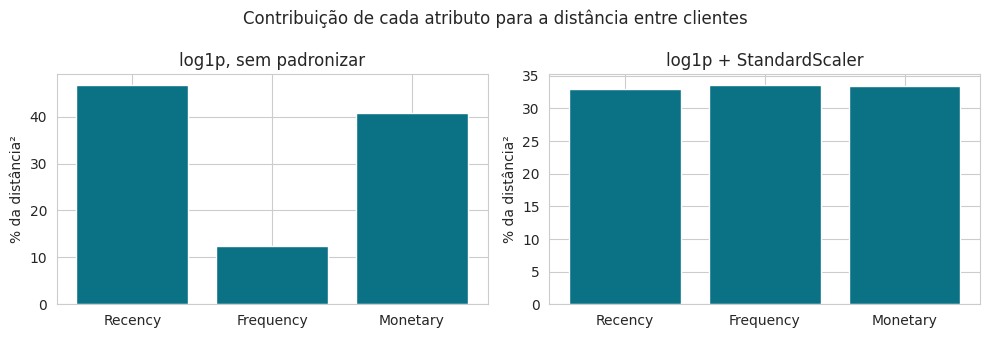

silhouette sem padronizar : 0.349
silhouette com padronizar : 0.339


In [8]:
# log1p aplicado em ambos os casos, para isolar o efeito da ESCALA
# (e não confundir com o efeito da assimetria, que já foi corrigido nos dois)
def fracao_da_distancia(X, cols, n_pares=6000, seed=RS):
    '''Quanto cada atributo contribui, em média, para a distância² entre dois clientes.'''
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=(n_pares, 2))
    d2 = (X[idx[:, 0]] - X[idx[:, 1]]) ** 2
    return pd.Series(d2.sum(axis=0) / d2.sum(), index=cols)

frac_sem = fracao_da_distancia(X_log, FEATURES)
frac_com = fracao_da_distancia(Z, FEATURES)

km_sem = KMeans(4, n_init=10, random_state=RS).fit(X_log)
km_com = KMeans(4, n_init=10, random_state=RS).fit(Z)
sil_sem = silhouette_score(X_log, km_sem.labels_)
sil_com = silhouette_score(Z, km_com.labels_)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, frac, titulo in zip(axes, [frac_sem, frac_com], ["log1p, sem padronizar", "log1p + StandardScaler"]):
    ax.bar(frac.index, frac.values * 100, color=PALETA[0])
    ax.set_ylabel("% da distância²")
    ax.set_title(titulo)
fig.suptitle("Contribuição de cada atributo para a distância entre clientes")
fig.tight_layout()
plt.show()

print(f"silhouette sem padronizar : {sil_sem:.3f}")
print(f"silhouette com padronizar : {sil_com:.3f}")

> **Leitura do resultado:** se `Monetary` concentra a maior parte da distância antes do `StandardScaler`, o agrupamento "sem padronizar" está, na prática, segmentando só por valor gasto — Recency e Frequency somem do cálculo mesmo aparecendo no código. A partir daqui, todo o notebook usa `Z` (log1p + StandardScaler).

## 4 · Item 1 — Implementação e comparação de algoritmos

Estrutura de resultados única para os três algoritmos, permitindo comparação direta ao final.

In [9]:
resultados = {
    "algoritmo": [], "n_clusters": [], "silhouette": [],
    "davies_bouldin": [], "calinski_harabasz": [], "tempo_execucao_s": [],
}

def registrar(nome, labels, X, tempo, apenas_nao_ruido=False):
    if apenas_nao_ruido:
        mask = labels != -1
        n_clusters = len(set(labels[mask]))
        if n_clusters < 2 or mask.sum() <= n_clusters:
            sil = db_score = ch_score = np.nan
        else:
            sil = silhouette_score(X[mask], labels[mask])
            db_score = davies_bouldin_score(X[mask], labels[mask])
            ch_score = calinski_harabasz_score(X[mask], labels[mask])
    else:
        n_clusters = len(set(labels))
        sil = silhouette_score(X, labels)
        db_score = davies_bouldin_score(X, labels)
        ch_score = calinski_harabasz_score(X, labels)
    resultados["algoritmo"].append(nome)
    resultados["n_clusters"].append(n_clusters)
    resultados["silhouette"].append(sil)
    resultados["davies_bouldin"].append(db_score)
    resultados["calinski_harabasz"].append(ch_score)
    resultados["tempo_execucao_s"].append(tempo)

### 4.1 · K-Means — escolha de K

Três perspectivas, nenhuma decide sozinha: cotovelo (inércia), silhueta e **estabilidade** (o cluster sobrevive à reamostragem?). O K final é desempatado por viabilidade de negócio — quantos segmentos a operação de marketing consegue de fato tratar de forma diferente.

In [10]:
def estabilidade(X, k, n_rep=20, frac=0.8, seed=RS):
    '''Reamostra 80% dos dados n_rep vezes; mede a concordância (ARI) com o agrupamento de referência.'''
    r = np.random.default_rng(seed)
    ref = KMeans(k, n_init=10, random_state=seed).fit(X)
    scores = []
    for _ in range(n_rep):
        idx = r.choice(len(X), size=int(frac * len(X)), replace=False)
        lab_amostra = KMeans(k, n_init=10, random_state=seed).fit_predict(X[idx])
        scores.append(adjusted_rand_score(ref.labels_[idx], lab_amostra))
    return np.mean(scores)

ks = range(2, 11)
inercia, silhueta_k, estab_k = [], [], []
for k in ks:
    m = KMeans(k, n_init=10, random_state=RS).fit(Z)
    inercia.append(m.inertia_)
    silhueta_k.append(silhouette_score(Z, m.labels_))
    estab_k.append(estabilidade(Z, k))

tabela_k = pd.DataFrame({
    "k": list(ks), "inercia": np.round(inercia, 1),
    "silhueta": np.round(silhueta_k, 3), "estabilidade_ARI": np.round(estab_k, 3),
})
tabela_k

,k,inercia,silhueta,estabilidade_ARI
0,2,6437.9,0.433,0.993
1,3,4823.0,0.338,0.955
2,4,3895.3,0.339,0.918
3,5,3254.9,0.317,0.887
4,6,2817.3,0.313,0.922
5,7,2513.7,0.309,0.970
6,8,2302.1,0.304,0.833
7,9,2132.1,0.295,0.738
8,10,1968.0,0.279,0.810


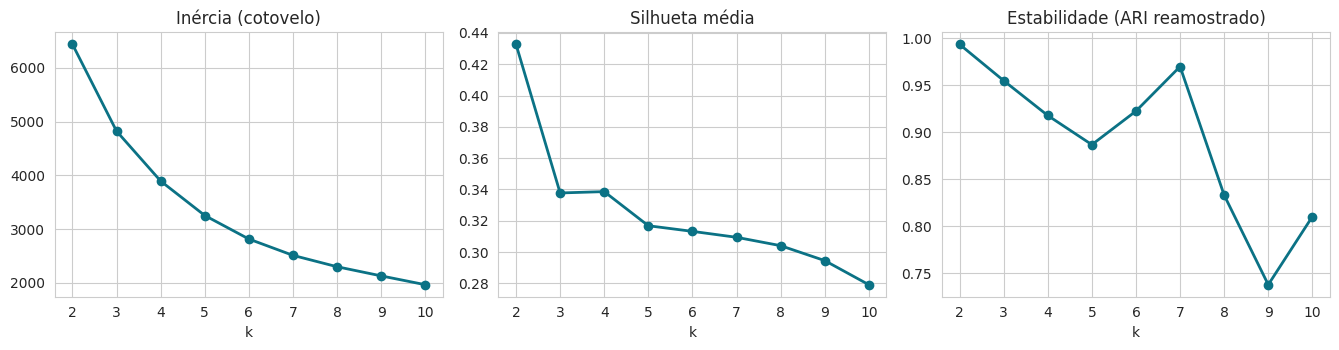

k de maior silhueta: 2 (não usado como K final — ver decisão na célula seguinte)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
for ax, val, titulo in zip(axes, [inercia, silhueta_k, estab_k],
                           ["Inércia (cotovelo)", "Silhueta média", "Estabilidade (ARI reamostrado)"]):
    ax.plot(list(ks), val, "o-", color=PALETA[0], lw=2, ms=6)
    ax.set_xlabel("k")
    ax.set_title(titulo)
fig.tight_layout()
plt.show()

k_silhueta = list(ks)[int(np.argmax(silhueta_k))]
print(f"k de maior silhueta: {k_silhueta} (não usado como K final — ver decisão na célula seguinte)")

In [12]:
# K_FINAL = 4 — o que as métricas dizem, sem forçar:
# - silhueta:     k=2 tem o pico; k=3 e k=4 empatam logo abaixo — a silhueta não
#                 distingue 3 de 4
# - inércia:      não há cotovelo nítido; a curva desacelera de forma gradual
# - estabilidade: k=3 e k=4 ficam no mesmo patamar alto (ARI > 0,9), longe da
#                 queda de k=8
# ou seja: entre 3 e 4 as métricas empatam. A escolha de 4 é de NEGÓCIO — um
# segmento a mais separa clientes novos de clientes recorrentes estabelecidos,
# que pedem ações diferentes (onboarding vs. retenção) — ver seção 6
K_FINAL = 4

t0 = time.time()
km_final = KMeans(K_FINAL, n_init=20, random_state=RS).fit(Z)
registrar(f"K-Means (k={K_FINAL})", km_final.labels_, Z, time.time() - t0)
rfm["cluster_kmeans"] = km_final.labels_
print(f"K-Means final: k={K_FINAL}, silhueta={silhouette_score(Z, km_final.labels_):.3f}")

K-Means final: k=4, silhueta=0.339


#### Convergência do K-Means

Dois pontos: quantas iterações o modelo final levou para convergir, e se inicializações diferentes chegam à mesma solução (ou ficam presas em mínimos locais diferentes).

iterações até convergir (modelo final): 16  (limite max_iter=300)
iterações (n_init=1)  : min=15  mediana=22  max=35
inércia final         : min=3895.2  max=3897.5  (modelo final: 3895.3)
mesma partição do modelo final (ARI > 0,99): 0/20 inicializações


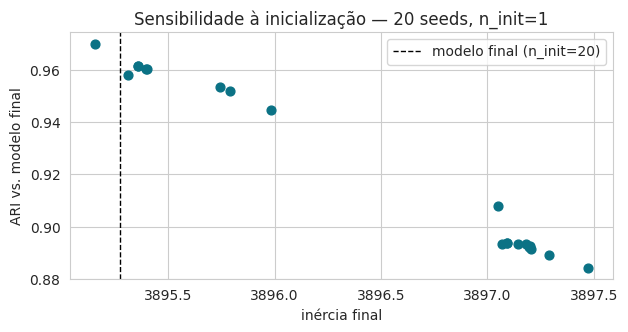

In [13]:
print(f"iterações até convergir (modelo final): {km_final.n_iter_}  (limite max_iter={km_final.max_iter})")

# 20 execuções com UMA inicialização cada (n_init=1) e seeds diferentes —
# isola a sensibilidade à inicialização que o n_init=20 do modelo final esconde
inercias_init, ari_init, iters_init = [], [], []
for s in range(20):
    m = KMeans(K_FINAL, n_init=1, random_state=s).fit(Z)
    inercias_init.append(m.inertia_)
    iters_init.append(m.n_iter_)
    ari_init.append(adjusted_rand_score(km_final.labels_, m.labels_))
inercias_init, ari_init = np.array(inercias_init), np.array(ari_init)

print(f"iterações (n_init=1)  : min={min(iters_init)}  mediana={int(np.median(iters_init))}  max={max(iters_init)}")
print(f"inércia final         : min={inercias_init.min():.1f}  max={inercias_init.max():.1f}  "
      f"(modelo final: {km_final.inertia_:.1f})")
print(f"mesma partição do modelo final (ARI > 0,99): {(ari_init > 0.99).sum()}/20 inicializações")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(inercias_init, ari_init, color=PALETA[0], s=40)
ax.axvline(km_final.inertia_, color="black", linestyle="--", lw=1, label="modelo final (n_init=20)")
ax.set_xlabel("inércia final")
ax.set_ylabel("ARI vs. modelo final")
ax.set_title("Sensibilidade à inicialização — 20 seeds, n_init=1")
ax.legend()
plt.show()

**Leitura:** o modelo final converge rápido (poucas iterações, muito abaixo do limite). Porém, as inicializações isoladas chegam a partições **ligeiramente diferentes** da final (ARI entre 0,88 e 0,97) com **inércia praticamente idêntica** (diferença < 0,1%). A função objetivo é "plana" perto do ótimo: há várias partições quase equivalentes, que diferem nos clientes de fronteira. O núcleo dos segmentos é estável; a fronteira não. Isso justifica `n_init=20` com `random_state` fixo (reprodutibilidade) e reforça que a atribuição de clientes limítrofes não deve ser tratada como exata.

### 4.2 · Clustering Hierárquico — linkage e dendrograma

In [14]:
# custo de memória do hierárquico é O(n²): acima de N_MAX_HIERARQUICO a base é
# amostrada; nesta base (~4,3 mil clientes) o limite não é atingido e o
# hierárquico roda na base inteira
N_MAX_HIERARQUICO = 5000
if len(Z) > N_MAX_HIERARQUICO:
    idx_amostra = np.random.default_rng(RS).choice(len(Z), N_MAX_HIERARQUICO, replace=False)
    Z_hier = Z[idx_amostra]
    print(f"amostrando {N_MAX_HIERARQUICO} de {len(Z)} clientes para o hierárquico (custo de memória)")
else:
    Z_hier = Z
    idx_amostra = np.arange(len(Z))
    print(f"hierárquico na base inteira ({len(Z):,} clientes) — sem amostragem")

links, silhueta_linkage, menor_cluster = {}, {}, {}
for linkage_m in ["ward", "complete", "average"]:
    t0 = time.time()
    Z_link = linkage(Z_hier, method=linkage_m)
    labels_h = fcluster(Z_link, t=K_FINAL, criterion="maxclust")
    tempo = time.time() - t0
    links[linkage_m] = Z_link
    silhueta_linkage[linkage_m] = silhouette_score(Z_hier, labels_h)
    tamanhos = np.sort(np.bincount(labels_h)[1:])[::-1]
    menor_cluster[linkage_m] = tamanhos.min()
    registrar(f"Hierárquico ({linkage_m})", labels_h, Z_hier, tempo)
    print(f"linkage={linkage_m:<9} silhueta={silhueta_linkage[linkage_m]:.3f}  tamanhos={tamanhos.tolist()}")

# a silhueta sozinha premia soluções degeneradas — um bloco gigante mais clusters
# de 1-3 pontos isolando outliers extremos. Só concorre a solução cujo menor
# cluster tem pelo menos 2% da base (um "segmento" de 1 cliente não é segmento)
MIN_FRAC_CLUSTER = 0.02
validos = {m: s for m, s in silhueta_linkage.items()
           if menor_cluster[m] >= MIN_FRAC_CLUSTER * len(Z_hier)}
LINKAGE_FINAL = max(validos, key=validos.get)
print(f"\nlinkages válidos (menor cluster >= {MIN_FRAC_CLUSTER:.0%} da base): {list(validos)}")
print(f"linkage escolhido para o dendrograma: {LINKAGE_FINAL} (silhueta={silhueta_linkage[LINKAGE_FINAL]:.3f})")

hierárquico na base inteira (4,317 clientes) — sem amostragem


linkage=ward      silhueta=0.240  tamanhos=[1593, 1147, 912, 665]


linkage=complete  silhueta=0.191  tamanhos=[2138, 2004, 100, 75]


linkage=average   silhueta=0.322  tamanhos=[4284, 25, 7, 1]

linkages válidos (menor cluster >= 2% da base): ['ward']
linkage escolhido para o dendrograma: ward (silhueta=0.240)


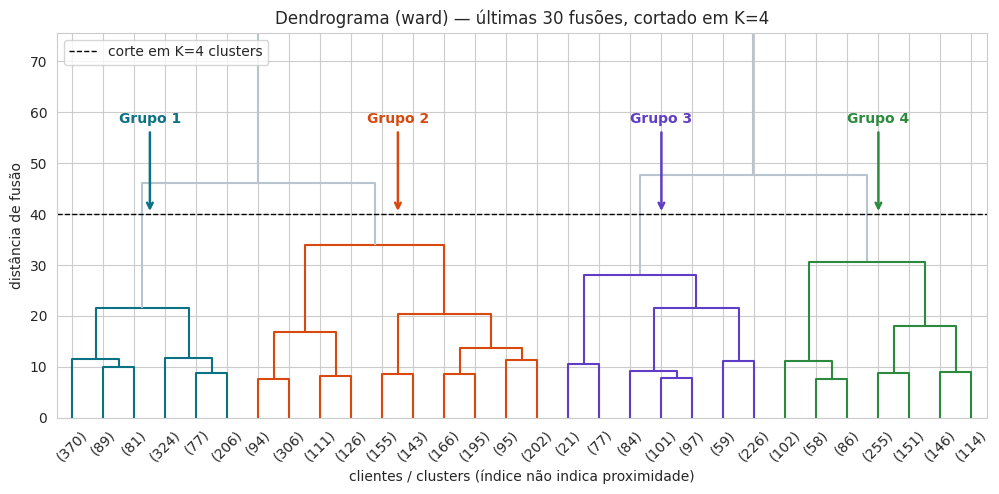

In [15]:
# dendrograma com o linkage escolhido na célula anterior (maior silhueta entre
# as soluções não degeneradas)
Z_link_final = links[LINKAGE_FINAL]
labels_hier_final = fcluster(Z_link_final, t=K_FINAL, criterion="maxclust")
rfm.loc[rfm.index[idx_amostra], "cluster_hier"] = labels_hier_final

# altura de corte que produz exatamente K_FINAL clusters — ponto médio entre a
# última fusão "aceita" (ainda gera K_FINAL grupos) e a próxima (juntaria dois deles)
n = len(Z_hier)
dist_ordenadas = Z_link_final[:, 2]
corte = (dist_ordenadas[n - K_FINAL - 1] + dist_ordenadas[n - K_FINAL]) / 2

# a cor de cada galho é definida explicitamente (via link_color_func), não pelo esquema
# automático do scipy — com truncate_mode="lastp" a separação real entre clusters
# pode ficar escondida dentro de uma super-folha comprimida, e a cor automática do
# scipy (baseada só no desenho truncado) pode contar grupos errado ou usar cores
# pouco distintas; aqui a cor de cada galho vem do cluster real (fcluster) dos
# clientes originais por trás dele, então linha e rótulo sempre batem
_cache_indices = {}
def indices_originais(node_id):
    if node_id < n:
        return [node_id]
    if node_id in _cache_indices:
        return _cache_indices[node_id]
    esq, dir_ = int(Z_link_final[node_id - n, 0]), int(Z_link_final[node_id - n, 1])
    res = indices_originais(esq) + indices_originais(dir_)
    _cache_indices[node_id] = res
    return res

_cor_por_cluster = {}
def cor_do_cluster(grupo):
    if grupo not in _cor_por_cluster:
        _cor_por_cluster[grupo] = PALETA[len(_cor_por_cluster) % len(PALETA)]
    return _cor_por_cluster[grupo]

def link_color_func(node_id):
    if Z_link_final[node_id - n, 2] > corte:
        return CINZA_RUIDO
    idx_orig = indices_originais(node_id)
    valores, contagens = np.unique(labels_hier_final[idx_orig], return_counts=True)
    return cor_do_cluster(valores[np.argmax(contagens)])

fig, ax = plt.subplots(figsize=(12, 5))
ddata = dendrogram(Z_link_final, truncate_mode="lastp", p=30, ax=ax, link_color_func=link_color_func)
ax.axhline(corte, color="black", linestyle="--", lw=1, label=f"corte em K={K_FINAL} clusters")

# grupo de cada folha exibida via índices originais (não via cor desenhada) — evita
# contar clusters errado quando a compressão do truncate_mode esconde a separação real
grupo_por_folha = []
for node_id in ddata["leaves"]:
    idx_orig = indices_originais(node_id)
    valores, contagens = np.unique(labels_hier_final[idx_orig], return_counts=True)
    grupo_por_folha.append(valores[np.argmax(contagens)])

grupo_atual = grupo_por_folha[0]
inicio = 0
segmentos = []
for i, g in enumerate(grupo_por_folha[1:], start=1):
    if g != grupo_atual:
        segmentos.append((grupo_atual, inicio, i - 1))
        grupo_atual = g
        inicio = i
segmentos.append((grupo_atual, inicio, len(grupo_por_folha) - 1))

# escalona a altura do rótulo quando dois grupos ficam próximos demais no eixo X
# (grupos minúsculos, tipo um outlier isolado ao lado de um cluster de 3 clientes,
# senão as setas e os textos se sobrepõem)
y_topo = ax.get_ylim()[1]
x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
DIST_MIN = x_range * 0.08

x_centros = [5 + 10 * (ini + fim) / 2 for _, ini, fim in segmentos]
niveis = [0]
for i in range(1, len(x_centros)):
    niveis.append(niveis[i - 1] + 1 if x_centros[i] - x_centros[i - 1] < DIST_MIN else 0)

for (g, ini, fim), x_centro, nivel in zip(segmentos, x_centros, niveis):
    cor = cor_do_cluster(g)
    y_texto = corte + (0.15 + 0.10 * nivel) * y_topo
    ax.annotate(
        f"Grupo {g}", xy=(x_centro, corte), xytext=(x_centro, y_texto),
        ha="center", fontsize=10, fontweight="bold", color=cor,
        arrowprops=dict(arrowstyle="->", color=cor, lw=1.8),
    )

ax.set_ylim(0, corte + (0.15 + 0.10 * max(niveis) + 0.15) * y_topo)
ax.set_title(f"Dendrograma ({LINKAGE_FINAL}) — últimas 30 fusões, cortado em K={K_FINAL}")
ax.set_xlabel("clientes / clusters (índice não indica proximidade)")
ax.set_ylabel("distância de fusão")
ax.legend(loc="upper left")
plt.show()

#### Corte ótimo da árvore

O corte acima usa `K_FINAL` para permitir comparação direta com o K-Means. Abaixo, o corte que a **própria árvore** sugere: o maior salto entre alturas de fusão consecutivas — cortar dentro desse salto separa grupos que só se juntariam a um custo desproporcional.

In [16]:
alturas = Z_link_final[:, 2]
# cortar entre alturas[-k] e alturas[-(k-1)] deixa exatamente k clusters
linhas = []
for k in range(2, 11):
    salto = alturas[-(k - 1)] - alturas[-k]
    lab_k = fcluster(Z_link_final, t=k, criterion="maxclust")
    linhas.append({"k": k, "salto_fusao": round(salto, 3),
                   "silhueta": round(silhouette_score(Z_hier, lab_k), 3)})
tabela_corte = pd.DataFrame(linhas)
k_corte = int(tabela_corte.loc[tabela_corte["salto_fusao"].idxmax(), "k"])
print(f"corte ótimo pela árvore ({LINKAGE_FINAL}): k={k_corte}  (maior salto entre fusões)")
tabela_corte

corte ótimo pela árvore (ward): k=2  (maior salto entre fusões)


,k,salto_fusao,silhueta
0,2,65.229,0.428
1,3,1.391,0.310
2,4,12.287,0.240
3,5,3.411,0.238
4,6,2.530,0.240
5,7,6.309,0.243
6,8,0.072,0.249
7,9,1.194,0.218
8,10,2.352,0.206


**Leitura:** a árvore Ward sugere k=2 como corte principal, com um salto de fusão muito maior que todos os outros. É a mesma divisão que a silhueta do K-Means favorece: clientes de alto engajamento vs. o restante. O **segundo maior salto está em k=4**, então a própria árvore oferece 4 grupos como o próximo corte natural, o que converge com a granularidade escolhida no K-Means.

### 4.3 · DBSCAN — k-distance graph para escolher `eps`

`MinPts` pela regra prática (≈2× dimensões); `eps` lido no "joelho" da curva k-distance.

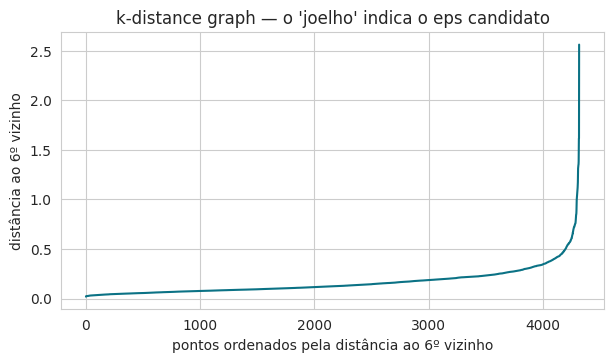

MinPts = 6
eps candidato (joelho via distância à corda) = 0.383 (ponto 4074 de 4317)


In [17]:
min_pts = 2 * Z.shape[1]
nn = NearestNeighbors(n_neighbors=min_pts).fit(Z)
dist_k, _ = nn.kneighbors(Z)
kdist = np.sort(dist_k[:, -1])

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(kdist, color=PALETA[0])
ax.set_xlabel(f"pontos ordenados pela distância ao {min_pts}º vizinho")
ax.set_ylabel(f"distância ao {min_pts}º vizinho")
ax.set_title("k-distance graph — o 'joelho' indica o eps candidato")
plt.show()

# heurística do "ponto mais distante da corda" (Kneedle): traça uma linha reta do
# primeiro ao último ponto da curva e acha o ponto que mais se afasta dela — mais
# robusto que "maior salto entre pontos consecutivos", que se deixa enganar por um
# disparo isolado bem no fim da cauda (poucos outliers extremos, não o joelho real)
x_norm = np.linspace(0, 1, len(kdist))
y_norm = (kdist - kdist.min()) / (kdist.max() - kdist.min())
corda = np.array([x_norm[-1], y_norm[-1]]) - np.array([x_norm[0], y_norm[0]])
corda_unit = corda / np.linalg.norm(corda)
pontos = np.stack([x_norm, y_norm], axis=1) - np.array([x_norm[0], y_norm[0]])
proj = pontos @ corda_unit
dist_perp = np.linalg.norm(pontos - np.outer(proj, corda_unit), axis=1)
idx_joelho = np.argmax(dist_perp)
eps_candidato = kdist[idx_joelho]

print(f"MinPts = {min_pts}")
print(f"eps candidato (joelho via distância à corda) = {eps_candidato:.3f} "
      f"(ponto {idx_joelho} de {len(kdist)})")

In [18]:
# validar eps: nem tudo virando ruído, nem tudo virando um cluster só
for eps in sorted({round(eps_candidato * f, 3) for f in (0.6, 0.8, 1.0, 1.2)}):
    db = DBSCAN(eps=eps, min_samples=min_pts).fit(Z)
    labels_db = db.labels_
    n_clusters_db = len(set(labels_db) - {-1})
    ruido_frac = (labels_db == -1).mean()
    print(f"eps={eps:<7} clusters={n_clusters_db:<3} ruído={ruido_frac:.1%}")

# EPS_FINAL = 0.8 × eps_candidato. Transparência sobre o critério: o joelho puro
# (1.0×) colapsa a base em poucos grupos; 0.8× foi escolhido para chegar a uma
# granularidade próxima da do K-Means, com fração de ruído plausível. É uma
# escolha orientada à comparação entre algoritmos, não uma otimização
# independente do DBSCAN
EPS_FINAL = round(eps_candidato * 0.8, 3)
t0 = time.time()
db_final = DBSCAN(eps=EPS_FINAL, min_samples=min_pts).fit(Z)
tempo_db = time.time() - t0
rfm["cluster_dbscan"] = db_final.labels_

registrar(f"DBSCAN (eps={EPS_FINAL:.2f})", db_final.labels_, Z, tempo_db, apenas_nao_ruido=True)
tamanhos_db = pd.Series(db_final.labels_).value_counts().sort_index()
print(f"\nDBSCAN final: {len(set(db_final.labels_) - {-1})} clusters, "
      f"{(db_final.labels_ == -1).mean():.1%} classificados como ruído (clientes atípicos)")
print(f"tamanhos (−1 = ruído): {tamanhos_db.to_dict()}")

eps=0.23    clusters=15  ruído=12.4%
eps=0.307   clusters=8   ruído=6.3%
eps=0.383   clusters=4   ruído=2.9%


eps=0.46    clusters=2   ruído=1.7%



DBSCAN final: 8 clusters, 6.3% classificados como ruído (clientes atípicos)
tamanhos (−1 = ruído): {-1: 272, 0: 1301, 1: 1418, 2: 478, 3: 809, 4: 20, 5: 6, 6: 6, 7: 7}


**Cruzamento K-Means × DBSCAN** — os dois algoritmos concordam, divergem ou um refina o outro?

In [19]:
crosstab_kmeans_dbscan = pd.crosstab(
    rfm["cluster_kmeans"], rfm["cluster_dbscan"], margins=True, margins_name="Total"
)
crosstab_kmeans_dbscan

cluster_dbscan,-1,0,1,2,3,4,5,6,7,Total
cluster_kmeans,,,,,,,,,,
0,61,652,19,290,159,0,0,0,0,1181
1,29,4,1171,61,344,0,0,0,0,1609
2,52,100,228,127,306,20,0,0,0,833
3,130,545,0,0,0,0,6,6,7,694
Total,272,1301,1418,478,809,20,6,6,7,4317


**Leitura** (nomes dos segmentos atribuídos na seção 6: 0 = Loyal Customers, 1 = Lost, 2 = New Customers, 3 = Champions):

- O DBSCAN **não refina** o K-Means; os dois recortam a base de forma diferente. O cluster 0 do DBSCAN junta a maior parte de Loyal Customers (652) e Champions (545) numa única região densa. Para o DBSCAN não há um vale de densidade separando esses dois perfis: o K-Means os separa por fronteira convexa, não por uma lacuna natural nos dados.
- **Lost** é o segmento que os dois algoritmos concordam em isolar: 1.171 dos 1.609 clientes caem no mesmo cluster de densidade.
- **New Customers** se espalha por vários clusters do DBSCAN e é o segmento menos coeso.
- Os clusters 4 a 7 (20, 6, 6 e 7 clientes) são micro-grupos, não segmentos acionáveis.
- O ruído (272 clientes) se concentra em Champions: são 130 clientes, quase metade de todo o ruído. Isso é coerente com esse segmento conter os compradores de volume extremo.

### 4.4 · Tabela comparativa

In [20]:
tabela_comparativa = pd.DataFrame(resultados).round(3)
tabela_comparativa

,algoritmo,n_clusters,silhouette,davies_bouldin,calinski_harabasz,tempo_execucao_s
0,K-Means (k=4),4,0.339,1.012,3342.318,0.042
1,Hierárquico (ward),4,0.240,1.312,2803.960,0.289
2,Hierárquico (complete),4,0.191,1.048,1513.553,0.321
3,Hierárquico (average),4,0.322,0.575,105.633,0.320
4,DBSCAN (eps=0.31),8,0.092,1.528,839.504,0.027


**Leitura da tabela:** nenhuma métrica decide sozinha, e as divergências têm causas identificáveis.

- **K-Means** tem a maior silhueta e o maior Calinski-Harabasz, com clusters de tamanho equilibrado.
- **Hierárquico (average)** tem o melhor Davies-Bouldin, mas é uma solução degenerada: 4.284 clientes num único bloco e três "clusters" de 25, 7 e 1 cliente, isto é, outliers isolados. O Calinski-Harabasz muito baixo (~106) expõe isso, e por essa razão ele ficou fora da escolha do dendrograma.
- **Hierárquico (ward)** é a alternativa não degenerada mais próxima do K-Means, com o segundo maior Calinski-Harabasz, mas perde em silhueta e Davies-Bouldin.
- **DBSCAN** tem as piores métricas, o que é esperado. Elas são calculadas só nos pontos que não são ruído, e silhueta e Davies-Bouldin favorecem grupos convexos, penalizando os clusters de forma arbitrária que o DBSCAN produz.
- **Tempo:** todos ficam abaixo de 1 s nesta base. O hierárquico é várias vezes mais lento que o K-Means e cresce O(n²) em memória, o que só pesa em bases maiores.

**Algoritmo final: K-Means.** Lidera em silhueta e Calinski-Harabasz entre as soluções não degeneradas, é estável sob reamostragem e tem centróides que permitem classificar clientes novos sem reprocessar a base.

## 5 · Diagnóstico de confiança

Antes de interpretar qualquer cluster: existe estrutura real nos dados, ou o algoritmo está "inventando" grupos em ruído (uma armadilha clássica do clustering)?

In [21]:
def hopkins(X, frac=0.1, seed=RS):
    '''~0.5 = sem estrutura de agrupamento; próximo de 1 = estrutura forte.'''
    r = np.random.default_rng(seed)
    n, d = X.shape
    m = max(int(frac * n), 5)
    amostra = X[r.choice(n, m, replace=False)]
    aleatorios = r.uniform(X.min(0), X.max(0), size=(m, d))
    nn2 = NearestNeighbors(n_neighbors=2).fit(X)
    u_dist, _ = nn2.kneighbors(aleatorios)
    w_dist, _ = nn2.kneighbors(amostra)
    U = u_dist[:, 0].sum()
    W = w_dist[:, 1].sum()  # segundo vizinho: o primeiro é o próprio ponto da amostra
    return U / (U + W)

h = hopkins(Z)
print(f"estatística de Hopkins: {h:.3f}  "
      f"({'distribuição não uniforme' if h > 0.7 else 'próxima de uniforme — reavaliar'})")

estatística de Hopkins: 0.944  (distribuição não uniforme)


**Leitura do Hopkins, com a ressalva necessária:** o valor de 0,94 indica que os dados estão longe de uma distribuição uniforme. Porém, com os pontos de referência sorteados uniformemente na caixa delimitadora, praticamente qualquer distribuição concentrada produz valores altos, inclusive um único blob. O Hopkins descarta o cenário de "ruído uniforme", mas **não prova** que existam grupos naturais bem separados.

Essa leitura se soma a outros sinais do notebook:
- a silhueta de 0,34 está na faixa de estrutura fraca (0,26–0,50) da escala de Kaufman & Rousseeuw;
- a convergência mostra partições diferentes com inércia praticamente igual (seção 4.1);
- o DBSCAN não encontra um vale de densidade entre Champions e Loyal Customers.

A conclusão consistente é que o espaço RFM é em boa parte um **contínuo**. A segmentação é uma **partição útil para ação**, não a descoberta de grupos naturalmente separados.

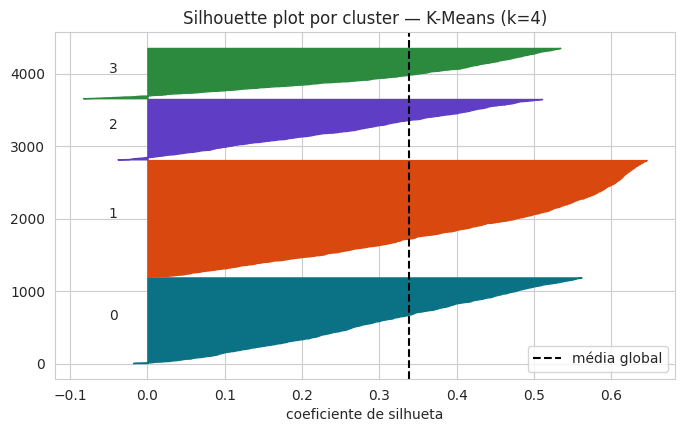

In [22]:
# silhouette plot por cluster — a média global (tabela da seção 4.4) pode esconder
# um cluster inteiro mal formado
sample_sil = silhouette_samples(Z, km_final.labels_)

fig, ax = plt.subplots(figsize=(8, 4.5))
y_lower = 10
for c in sorted(set(km_final.labels_)):
    vals = np.sort(sample_sil[km_final.labels_ == c])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=PALETA[c % len(PALETA)])
    ax.text(-0.05, y_lower + len(vals) / 2, str(c))
    y_lower = y_upper + 10
ax.axvline(silhouette_score(Z, km_final.labels_), color="black", linestyle="--", label="média global")
ax.set_xlabel("coeficiente de silhueta")
ax.set_title(f"Silhouette plot por cluster — K-Means (k={K_FINAL})")
ax.legend()
plt.show()

In [23]:
# estabilidade do K final escolhido — mesma lógica da seção 4.1, reportada para o modelo escolhido
print(f"estabilidade (ARI médio, reamostragem 80%, 20 repetições) do k={K_FINAL}: "
      f"{estabilidade(Z, K_FINAL):.3f}")

estabilidade (ARI médio, reamostragem 80%, 20 repetições) do k=4: 0.918


## 6 · Item 2 — Nomeação e visualização dos clusters

Modelo usado como referência para as visualizações e o relatório: **K-Means final** (`km_final`, k=4).

Os segmentos são nomeados **antes** dos gráficos, para que todas as figuras usem os nomes de negócio em vez de números de cluster. A regra usa R, F e M frente à mediana global, e duas variáveis auxiliares (Tenure e Atraso, seção 2) para distinguir casos que o RFM puro confunde: cliente novo vs. recorrente, e recorrente dentro do próprio ritmo vs. atrasado.

In [24]:
perfil = rfm.groupby("cluster_kmeans")[FEATURES + ["Tenure", "Atraso"]].median()
ref_global = rfm[FEATURES + ["Tenure"]].median()

def nomear_cluster(row, ref):
    recency_baixa = row["Recency"] <= ref["Recency"]
    frequency_alta = row["Frequency"] >= ref["Frequency"]
    monetary_alto = row["Monetary"] >= ref["Monetary"]
    cliente_novo = row["Tenure"] < ref["Tenure"]
    dentro_do_ciclo = row["Atraso"] <= 1          # ainda não passou do próprio ritmo de compra
    if recency_baixa and frequency_alta and monetary_alto:
        return "Champions"
    if recency_baixa and cliente_novo:
        return "New Customers"
    if frequency_alta and dentro_do_ciclo:
        return "Loyal Customers"
    if frequency_alta or monetary_alto:
        return "At Risk"
    return "Lost"

nomes_cluster = perfil.apply(lambda row: nomear_cluster(row, ref_global), axis=1)
# dois clusters com o mesmo nome indicariam regra mal calibrada — sufixo explícito
duplicado = nomes_cluster.duplicated(keep=False)
nomes_cluster[duplicado] = nomes_cluster[duplicado] + " (" + nomes_cluster.index[duplicado].astype(str) + ")"
rfm["segmento"] = rfm["cluster_kmeans"].map(nomes_cluster)

contagem = rfm["cluster_kmeans"].value_counts().sort_index()
receita_cluster = rfm.groupby("cluster_kmeans")["Monetary"].sum()
perfil_nomeado = perfil.copy()
perfil_nomeado.insert(0, "nome", nomes_cluster)
perfil_nomeado["clientes"] = contagem
perfil_nomeado["clientes_%"] = (contagem / contagem.sum() * 100).round(1)
perfil_nomeado["receita_total"] = receita_cluster.round(2)
perfil_nomeado["receita_%"] = (receita_cluster / receita_cluster.sum() * 100).round(1)
perfil_nomeado = perfil_nomeado.sort_values("receita_total", ascending=False)

# ordem (por receita) e cores (por ordem alfabética — mesmo mapeamento do dashboard)
ORDEM_SEG = perfil_nomeado["nome"].tolist()
COR_SEG = {s: PALETA[i % len(PALETA)] for i, s in enumerate(sorted(ORDEM_SEG))}

print("referência global (mediana):", ref_global.round(1).to_dict())
perfil_nomeado.round(2)

referência global (mediana): {'Recency': 51.0, 'Frequency': 2.0, 'Monetary': 658.3, 'Tenure': 249.0}


,nome,Recency,Frequency,Monetary,Tenure,Atraso,clientes,clientes_%,receita_total,receita_%
cluster_kmeans,,,,,,,,,,
3,Champions,8.0,10.0,3717.74,358.0,0.25,694,16.1,5357515.77,64.4
0,Loyal Customers,53.0,4.0,1325.29,280.0,0.75,1181,27.4,1953532.16,23.5
1,Lost,177.0,1.0,291.54,219.0,2.21,1609,37.3,553247.20,6.7
2,New Customers,17.0,2.0,460.40,67.0,0.15,833,19.3,448999.82,5.4


**Validação dos nomes** (tabela acima; referência global: R = 51 dias, F = 2 pedidos, M = £ 658, Tenure = 249 dias):

- **Champions** (R 8, F 10, M £ 3.718): acima da mediana global nos três eixos. Compra em média a cada ~1 mês e está bem dentro do próprio ciclo (Atraso 0,25).
- **Loyal Customers** (R 53, F 4, M £ 1.325): a Recency fica ligeiramente acima da mediana global (53 vs. 51), e pela regra RFM pura isso bastaria para chamá-los de "At Risk". O Atraso mediano de 0,75, porém, mostra que esses clientes compram a cada ~2 meses e ainda estão **dentro do próprio ciclo**. São recorrentes estabelecidos (Tenure de 280 dias), não clientes em fuga.
- **New Customers** (R 17, F 2, M £ 460): recentes, com Tenure mediana de 67 dias contra 249 da base, ou seja, a maioria entrou há poucos meses. Sem o Tenure, a regra os classificaria como "Loyal Customers", só porque F = 2 empata com a mediana global. Ressalva: cerca de um quarto do segmento já está na base há 7 meses ou mais, com baixa frequência. Esse subgrupo é mais "Promising" do que novo de fato.
- **Lost** (R 177, F 1, M £ 292): 73% compraram uma única vez, e os poucos recorrentes já passaram do dobro do próprio ciclo (Atraso 2,2).

Não há um segmento "At Risk" inteiro. O risco de churn aparece em nível **individual**, dentro de segmentos saudáveis, e é tratado pelo alerta de atraso da seção 7.2.

Com k = 3, Loyal Customers e New Customers se fundem num único grupo (1.050 + 625 clientes). O quarto segmento existe justamente para separar dois perfis que pedem ações diferentes: retenção e onboarding.

variância explicada: [0.753 0.187 0.06 ]  (acumulada: [0.753 0.94  1.   ])


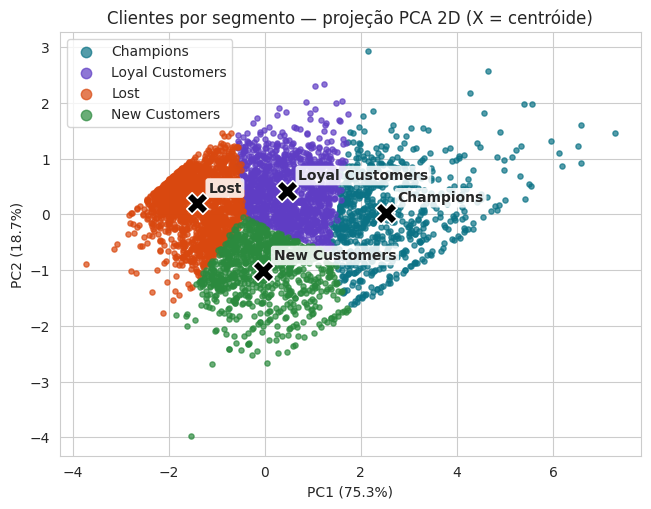

In [25]:
pca = PCA(n_components=3, random_state=RS).fit(Z)
Z_pca = pca.transform(Z)
cent_pca = pca.transform(km_final.cluster_centers_)
print(f"variância explicada: {pca.explained_variance_ratio_.round(3)}  "
      f"(acumulada: {pca.explained_variance_ratio_.cumsum().round(3)})")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for seg in ORDEM_SEG:
    mask = (rfm["segmento"] == seg).values
    ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1], c=COR_SEG[seg], s=14, alpha=0.7, label=seg)
for c, (x, y) in enumerate(cent_pca[:, :2]):
    ax.scatter(x, y, marker="X", s=240, c="black", edgecolors="white", linewidths=1.2)
    ax.annotate(nomes_cluster[c], (x, y), xytext=(8, 8), textcoords="offset points", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Clientes por segmento — projeção PCA 2D (X = centróide)")
ax.legend(markerscale=2)
plt.show()

**Interpretação dos componentes principais** — os *loadings* mostram o peso de cada feature original (Recency, Frequency, Monetary) em cada componente, permitindo dizer o que PC1 e PC2 representam em termos de negócio, não só em % de variância.

In [26]:
loadings = pd.DataFrame(
    pca.components_.T, index=FEATURES, columns=["PC1", "PC2", "PC3"]
).round(3)
loadings

,PC1,PC2,PC3
Recency,-0.511,0.851,0.120
Frequency,0.618,0.267,0.740
Monetary,0.597,0.453,-0.662


**Leitura de negócio dos componentes:**

- **PC1** (75,3% da variância): Frequency e Monetary puxam no mesmo sentido, e Recency no sentido oposto. É essencialmente um eixo de **valor/engajamento geral**: um cliente com PC1 alto compra com frequência, gasta bastante e comprou recentemente (Recency baixo inverte o sinal). É a dimensão que mais separa "cliente bom" de "cliente ruim" de forma agregada.
- **PC2** (18,7% da variância): dominado por Recency, com contribuição secundária de Monetary e menor de Frequency. Captura a parte de "há quanto tempo o cliente não compra" que o PC1 não explica. Um cliente com PC2 alto está inativo há mais tempo, mas ainda carrega algum peso histórico de gasto, e esse é o eixo que separa Lost dos demais.
- **PC3** (6,0% da variância): contribuição residual, sem interpretação individual. Com três features, os três componentes somam 100%, e PC1 + PC2 já cobrem 94,0% da variância, acima dos 80% exigidos para a projeção 2D.

In [27]:
fig3d = go.Figure()
for seg in ORDEM_SEG:
    mask = (rfm["segmento"] == seg).values
    fig3d.add_trace(go.Scatter3d(
        x=Z_pca[mask, 0], y=Z_pca[mask, 1], z=Z_pca[mask, 2], mode="markers", name=seg,
        marker=dict(size=3, color=COR_SEG[seg], opacity=0.75),
    ))
fig3d.add_trace(go.Scatter3d(
    x=cent_pca[:, 0], y=cent_pca[:, 1], z=cent_pca[:, 2], mode="markers+text",
    text=[nomes_cluster[c] for c in range(K_FINAL)], name="centróides",
    marker=dict(size=9, color="black", symbol="x"),
))
fig3d.update_layout(
    title="Clientes por segmento — projeção PCA 3D",
    scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3"),
    width=800, height=600,
)
fig3d.show()

In [28]:
# perfil por segmento (medianas na escala original — mais interpretável que Z)
perfil_rfm = rfm.groupby("segmento")[FEATURES].median().loc[ORDEM_SEG]

# normaliza em espaço log1p, não na escala original — um único segmento extremo em
# Frequency/Monetary (mesmo problema de escala da seção 3) dominaria o min-max e
# esmagaria a diferença visual entre os demais
perfil_log = np.log1p(perfil_rfm)
perfil_norm = (perfil_log - perfil_log.min()) / (perfil_log.max() - perfil_log.min())

# no radar, Recency é invertida: assim "mais para fora" significa "melhor" nos três
# eixos (mais recente, mais frequente, mais valor) e a área do polígono lê-se como valor
radar = perfil_norm.copy()
radar["Recency"] = 1 - radar["Recency"]
eixos = ["Recency (invertida)", "Frequency", "Monetary"]

fig_radar = go.Figure()
for seg in radar.index:
    fig_radar.add_trace(go.Scatterpolar(
        r=radar.loc[seg].values, theta=eixos, fill="toself", name=seg, line_color=COR_SEG[seg],
    ))
fig_radar.update_layout(
    title="Perfil normalizado por segmento (mediana de R, F, M — mais para fora = melhor)",
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    width=700, height=550,
)
fig_radar.show()

In [29]:
# tabela crua (sem normalizar) — útil para conferir se algum segmento é extremo
# de verdade, em vez de artefato de escala do gráfico
perfil_rfm.assign(clientes=rfm["segmento"].value_counts())

,Recency,Frequency,Monetary,clientes
segmento,,,,
Champions,8.0,10.0,3717.745,694
Loyal Customers,53.0,4.0,1325.290,1181
Lost,177.0,1.0,291.540,1609
New Customers,17.0,2.0,460.400,833


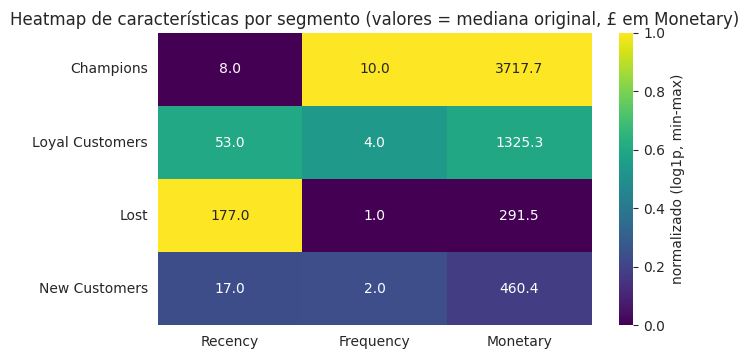

In [30]:
fig, ax = plt.subplots(figsize=(7, 3.8))
sns.heatmap(perfil_norm, annot=perfil_rfm.round(1), fmt="", cmap="viridis", ax=ax,
            cbar_kws={"label": "normalizado (log1p, min-max)"})
ax.set_title("Heatmap de características por segmento (valores = mediana original, £ em Monetary)")
ax.set_ylabel("")
plt.show()

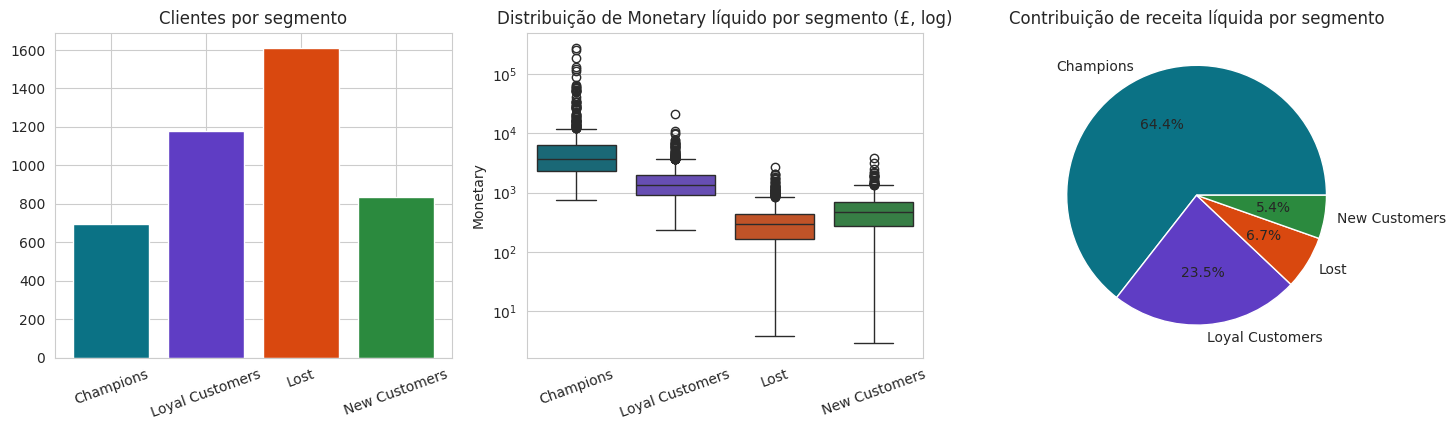

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
cores_ordem = [COR_SEG[s] for s in ORDEM_SEG]

cont_seg = rfm["segmento"].value_counts().loc[ORDEM_SEG]
axes[0].bar(ORDEM_SEG, cont_seg.values, color=cores_ordem)
axes[0].set_title("Clientes por segmento")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=rfm, x="segmento", y="Monetary", order=ORDEM_SEG, hue="segmento",
            palette=COR_SEG, legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Distribuição de Monetary líquido por segmento (£, log)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

receita_seg = rfm.groupby("segmento")["Monetary"].sum().loc[ORDEM_SEG]
axes[2].pie(receita_seg.values, labels=ORDEM_SEG, autopct="%1.1f%%", colors=cores_ordem)
axes[2].set_title("Contribuição de receita líquida por segmento")

fig.tight_layout()
plt.show()

## 7 · Perfil comportamental e sinais de risco

**Perfil comportamental de cada segmento** (valores em £, receita líquida):

- **Champions**: 694 clientes (16% da base) e **64,4% da receita**. Compram a cada ~1 mês, com a maior frequência e o maior gasto por cliente. A dependência é alta: perder uma fração pequena desse grupo tem impacto desproporcional na receita.
- **Loyal Customers**: 1.181 clientes (27%) e 23,5% da receita. São recorrentes estabelecidos com ciclo de ~2 meses e, na mediana, dentro do próprio ritmo. É onde está a maior receita em risco individual: 216 clientes já passaram do dobro do próprio ciclo (seção 7.2).
- **New Customers**: 833 clientes (19%) e 5,4% da receita. São recentes e de ticket baixo, e 32% ainda têm um único pedido. O desafio é converter a 2ª e a 3ª compra (onboarding), não reativar.
- **Lost**: 1.609 clientes (37%, o maior segmento) e 6,7% da receita. 73% compraram uma única vez, há cerca de 6 meses. Reativação em massa tende a ter retorno baixo por cliente; os 210 recorrentes em alerta dentro do segmento são o subgrupo que justifica esforço.

### 7.1 · Taxa de cancelamento/devolução por segmento

Overlay sobre os segmentos já formados — não muda o RFM nem o agrupamento, só adiciona uma leitura de risco.
Calculada a partir do `df_raw` como `notas 'C' / pedidos totais` por cliente. No UCI Online Retail, as notas com prefixo `C` incluem tanto cancelamentos de pedido quanto devoluções e créditos de compras anteriores — por isso a métrica é tratada como **taxa de cancelamento/devolução**, não apenas cancelamento.

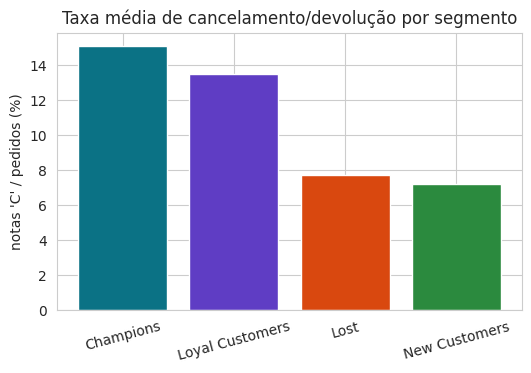

,nome,clientes,receita_%,taxa_cancelamento_%,devolucao_media_%_valor
cluster_kmeans,,,,,
3,Champions,694,64.4,15.1,2.4
0,Loyal Customers,1181,23.5,13.5,2.3
1,Lost,1609,6.7,7.7,1.9
2,New Customers,833,5.4,7.2,1.6


In [32]:
# taxa de cancelamento por cliente — usa df_raw (tem os pedidos "C..." que df já descartou)
df_com_cliente = df_raw.dropna(subset=["CustomerID"]).copy()
df_com_cliente["CustomerID"] = df_com_cliente["CustomerID"].astype(int)
df_com_cliente["cancelado"] = df_com_cliente["InvoiceNo"].astype(str).str.startswith("C")

pedidos = df_com_cliente.drop_duplicates("InvoiceNo")[["InvoiceNo", "CustomerID", "cancelado"]]
taxa_cancelamento = pedidos.groupby("CustomerID").agg(
    pedidos_totais=("InvoiceNo", "nunique"),
    pedidos_cancelados=("cancelado", "sum"),
)
taxa_cancelamento["taxa_cancelamento"] = (
    taxa_cancelamento["pedidos_cancelados"] / taxa_cancelamento["pedidos_totais"]
)

rfm = rfm.merge(taxa_cancelamento["taxa_cancelamento"], on="CustomerID", how="left")
perfil_nomeado["taxa_cancelamento_%"] = (
    rfm.groupby("cluster_kmeans")["taxa_cancelamento"].mean() * 100
).round(1)
# devolução em VALOR: média da fração devolvida por cliente (e não soma/soma,
# que um único cliente extremo — ex.: 16446, £168 mil comprados e devolvidos —
# domina sozinho)
rfm["fracao_devolvida"] = (-rfm["Devolucoes"] / rfm["MonetaryBruto"]).clip(0, 1)
perfil_nomeado["devolucao_media_%_valor"] = (
    rfm.groupby("cluster_kmeans")["fracao_devolvida"].mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(perfil_nomeado["nome"], perfil_nomeado["taxa_cancelamento_%"],
       color=[COR_SEG[s] for s in perfil_nomeado["nome"]])
ax.set_ylabel("notas 'C' / pedidos (%)")
ax.set_title("Taxa média de cancelamento/devolução por segmento")
plt.xticks(rotation=15)
plt.show()

perfil_nomeado[["nome", "clientes", "receita_%", "taxa_cancelamento_%", "devolucao_media_%_valor"]].sort_values(
    "taxa_cancelamento_%", ascending=False
)

**Leitura:** a taxa de cancelamento/devolução **por nota** cresce com o engajamento. Champions (15,1%) e Loyal Customers (13,5%) ficam em cerca do dobro de Lost e New Customers (~7,5%). Como a métrica já é uma taxa (normalizada pelo número de pedidos), o volume de pedidos, por si só, não explica a diferença.

**Em valor**, porém, a fração devolvida por cliente é baixa e parecida entre os segmentos (~2%). A leitura mais provável é que clientes de alto volume, com perfil de atacado/revenda, fazem muitos **ajustes pequenos**: cancelam e refazem pedidos ou devolvem itens pontuais, sem grandes devoluções. Isso é um sinal de **atrito operacional** no processo de compra dos melhores clientes, mais do que de perda de receita. Vale investigar o fluxo de pedido (erros de quantidade, disponibilidade de estoque), não apenas a estratégia comercial.

### 7.2 · Alerta individual de atraso

O K-Means agrupa por **perfil**, não por **momento**: um cliente recorrente pode estar num segmento saudável e, individualmente, já ter passado muito do seu ritmo normal de compra. O alerta abaixo marca clientes recorrentes (2+ pedidos) com `Atraso > 2` — mais do que o dobro do próprio intervalo médio sem comprar. É uma lista de ação para retenção, complementar aos segmentos.

In [33]:
LIMIAR_ATRASO = 2
rfm["alerta_atraso"] = (rfm["Frequency"] >= 2) & (rfm["Atraso"] > LIMIAR_ATRASO)

alerta = rfm.groupby("segmento").agg(
    clientes=("CustomerID", "count"),
    recorrentes=("Frequency", lambda s: (s >= 2).sum()),
    em_alerta=("alerta_atraso", "sum"),
    receita_em_alerta=("Monetary", lambda s: s[rfm.loc[s.index, "alerta_atraso"]].sum()),
).loc[ORDEM_SEG]
alerta["em_alerta_%_recorrentes"] = (alerta["em_alerta"] / alerta["recorrentes"] * 100).round(1)
alerta["receita_em_alerta"] = alerta["receita_em_alerta"].round(0)
print(f"total em alerta: {rfm['alerta_atraso'].sum():,} clientes, "
      f"£ {rfm.loc[rfm['alerta_atraso'], 'Monetary'].sum():,.0f} de receita histórica "
      f"({rfm.loc[rfm['alerta_atraso'], 'Monetary'].sum() / rfm['Monetary'].sum():.1%} do total)")
alerta

total em alerta: 457 clientes, £ 631,444 de receita histórica (7.6% do total)


,clientes,recorrentes,em_alerta,receita_em_alerta,em_alerta_%_recorrentes
segmento,,,,,
Champions,694,694,13,142169.0,1.9
Loyal Customers,1181,1155,216,383690.0,18.7
Lost,1609,427,210,96286.0,49.2
New Customers,833,566,18,9298.0,3.2


## 8 · Item 3 — Insumos para o relatório executivo

O relatório executivo em si **não fica neste notebook** — é um documento separado (`relatorio_executivo.pdf`), pensado para leitura por quem não vai abrir código. A célula abaixo concentra os números que entram nele.

In [34]:
print("=== Números do relatório executivo (valores em £) ===\n")
print(f"K_FINAL usado                 : {K_FINAL}")
print(f"Silhouette (K-Means final)    : {silhouette_score(Z, km_final.labels_):.3f}")
print(f"Estabilidade (ARI reamostrado): {estabilidade(Z, K_FINAL):.3f}")
print(f"Hopkins                       : {h:.3f}")
print(f"Data de referência (RFM)      : {data_referencia.date()}")
print(f"Clientes segmentados          : {len(rfm):,}")
print(f"Receita líquida total         : £ {rfm['Monetary'].sum():,.0f}  "
      f"(bruta £ {rfm['MonetaryBruto'].sum():,.0f})")
print()
print("Tabela completa por segmento:")
perfil_nomeado.round(2)

=== Números do relatório executivo (valores em £) ===

K_FINAL usado                 : 4


Silhouette (K-Means final)    : 0.339


Estabilidade (ARI reamostrado): 0.918
Hopkins                       : 0.944
Data de referência (RFM)      : 2011-12-10
Clientes segmentados          : 4,317
Receita líquida total         : £ 8,313,295  (bruta £ 8,824,675)

Tabela completa por segmento:


,nome,Recency,Frequency,Monetary,Tenure,Atraso,clientes,clientes_%,receita_total,receita_%,taxa_cancelamento_%,devolucao_media_%_valor
cluster_kmeans,,,,,,,,,,,,
3,Champions,8.0,10.0,3717.74,358.0,0.25,694,16.1,5357515.77,64.4,15.1,2.4
0,Loyal Customers,53.0,4.0,1325.29,280.0,0.75,1181,27.4,1953532.16,23.5,13.5,2.3
1,Lost,177.0,1.0,291.54,219.0,2.21,1609,37.3,553247.20,6.7,7.7,1.9
2,New Customers,17.0,2.0,460.40,67.0,0.15,833,19.3,448999.82,5.4,7.2,1.6


## 9 · Exportação para o dashboard

Gera `rfm_clusters.csv`, consumido pelo dashboard Streamlit (`streamlitapp.py`). Rodar `streamlit run streamlitapp.py` na mesma pasta onde este CSV foi salvo (dentro de `data/`).

In [35]:
import os

os.makedirs("data", exist_ok=True)

rfm_export = rfm.copy()
rfm_export["PC1"] = Z_pca[:, 0]
rfm_export["PC2"] = Z_pca[:, 1]
rfm_export["segmento"] = rfm_export["cluster_kmeans"].map(perfil_nomeado["nome"])

colunas_export = ["CustomerID", "Recency", "Frequency", "Monetary", "PC1", "PC2", "segmento"]
rfm_export[colunas_export].to_csv("data/rfm_clusters.csv", index=False)

print(f"exportado: data/rfm_clusters.csv ({len(rfm_export)} linhas)")
rfm_export[colunas_export].head()

exportado: data/rfm_clusters.csv (4317 linhas)


,CustomerID,Recency,Frequency,Monetary,PC1,PC2,segmento
0,12347,2,7,4310.00,2.564325,-0.792555,Champions
1,12348,75,4,1797.24,0.486377,0.757357,Loyal Customers
2,12349,19,1,1757.55,0.156737,-0.455560,New Customers
3,12350,310,1,334.40,-1.686075,0.683013,Lost
4,12352,36,8,1545.41,1.219831,0.474817,Loyal Customers
